# Homework 12 — Results Reporting & Delivery Design

## Audience and decision context

**Primary audience:** Portfolio / risk manager.

**Decision:** Decide whether the baseline analytical conclusion is robust enough to use for planning, or whether changes in data-handling assumptions materially alter expected return and risk.

This notebook is the **technical peer version**. It generates a concise stakeholder-facing report in `reports/final_report.md`, exports polished figures to `reports/images/`, and saves the sensitivity table to `data/processed/`.

### Deliverable design

The stakeholder report emphasizes:
- decision-oriented headlines,
- 3 self-contained visuals,
- plain-language assumptions and risks,
- quantified sensitivity to alternative assumptions,
- a clear “What this means for you” section.

The notebook preserves the calculations and reproducibility details for analysts.

**Reproducibility:** deterministic fallback data are used when no external results file is present.


## 1. Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 101
np.random.seed(SEED)

# Resolve the homework directory whether launched from the repo root
# or from homework/homework12.
cwd = Path.cwd()
if (cwd / "reports").exists() and (cwd / "data").exists():
    HOMEWORK_DIR = cwd
elif (cwd / "homework" / "homework12").exists():
    HOMEWORK_DIR = cwd / "homework" / "homework12"
else:
    HOMEWORK_DIR = cwd

DATA_DIR = HOMEWORK_DIR / "data" / "processed"
REPORTS_DIR = HOMEWORK_DIR / "reports"
IMG_DIR = REPORTS_DIR / "images"

for p in [DATA_DIR, REPORTS_DIR, IMG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Seed:", SEED)
print("Homework directory:", HOMEWORK_DIR.resolve())


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\yifunger\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Seed: 101
Homework directory: C:\Users\yifunger\Documents\Codex\2026-08-18\new-chat\work\bootcamp_Yifang_Qiu\homework\homework12


## 2. Load stakeholder results

The starter provides three decision scenarios:

- **Baseline:** median imputation / standard treatment
- **Alternative imputation:** mean imputation
- **Alternative outlier rule:** 3-sigma outlier treatment

If `data/processed/final_results.csv` is missing, the notebook creates the starter-compatible synthetic fallback below.


In [2]:
data_path = DATA_DIR / "final_results.csv"

if data_path.exists():
    df = pd.read_csv(data_path)
else:
    df = pd.DataFrame({
        "scenario": ["baseline", "alt_impute", "alt_outlier"],
        "return": [0.120, 0.110, 0.135],
        "volatility": [0.180, 0.185, 0.190],
        "sharpe": [0.56, 0.49, 0.61],
        "assumption": ["baseline", "imputation", "outlier_rule"],
        "value": ["median", "mean", "3sigma"],
    })
    df.to_csv(data_path, index=False)

scenario_labels = {
    "baseline": "Baseline",
    "alt_impute": "Mean imputation",
    "alt_outlier": "3σ outlier rule",
}
df["scenario_label"] = df["scenario"].map(scenario_labels)

df


,scenario,return,volatility,sharpe,assumption,value,scenario_label
0,baseline,0.120,0.180,0.56,baseline,median,Baseline
1,alt_impute,0.110,0.185,0.49,imputation,mean,Mean imputation
2,alt_outlier,0.135,0.190,0.61,outlier_rule,3sigma,3σ outlier rule


## 3. Executive summary

- **Baseline remains a reasonable planning case:** expected return is **12.0%** with **18.0% volatility** and Sharpe **0.56**.
- **Results are sensitive to assumptions, but not directionally unstable:** mean imputation reduces expected return by **1.0 percentage point**, while the 3σ outlier rule increases it by **1.5 percentage points**.
- **Decision implication:** use the baseline for planning only with explicit sensitivity bounds; the outlier-treatment scenario offers higher return but also higher volatility, so it should not be interpreted as a free improvement.


## 4. Chart 1 — Risk–return trade-off

**What the plot shows:** expected return versus volatility for each scenario.

**Stakeholder insight:** the 3σ outlier scenario has the highest expected return, but it also carries the highest volatility. Mean imputation moves in the unfavorable direction: slightly lower expected return and slightly higher volatility than baseline.

**Assumption / limitation:** these are scenario summaries, not guaranteed future outcomes. The chart compares model outputs under different assumptions; it does not prove that one assumption is economically “true.”


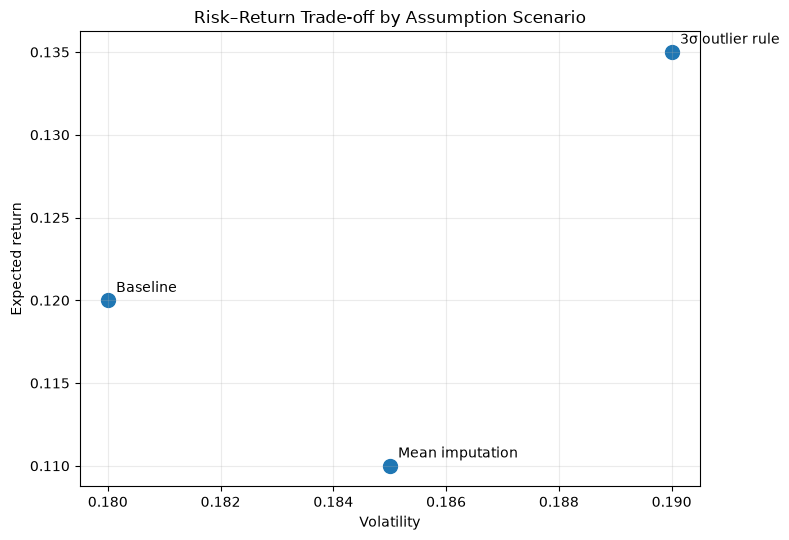

In [3]:
plt.figure(figsize=(8, 5.5))
plt.scatter(df["volatility"], df["return"], s=100)

for _, row in df.iterrows():
    plt.annotate(
        row["scenario_label"],
        (row["volatility"], row["return"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.xlabel("Volatility")
plt.ylabel("Expected return")
plt.title("Risk–Return Trade-off by Assumption Scenario")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(IMG_DIR / "risk_return_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Chart 2 — Quantified sensitivity versus baseline

This chart converts scenario changes into **percentage-point differences from baseline**, making the sensitivity easier to interpret than raw levels alone.

**Stakeholder insight:** mean imputation reduces expected return by 1.0 pp, while the 3σ rule raises return by 1.5 pp. Both alternatives slightly increase volatility.

**Assumption / limitation:** the magnitude of these changes is conditional on the starter scenario design. Sensitivity analysis shows dependence on assumptions; it is not a forecast interval.


In [4]:
baseline = df.loc[df["scenario"] == "baseline"].iloc[0]

sensitivity = df.copy()
sensitivity["return_delta_pp"] = (sensitivity["return"] - baseline["return"]) * 100
sensitivity["volatility_delta_pp"] = (sensitivity["volatility"] - baseline["volatility"]) * 100
sensitivity["sharpe_delta"] = sensitivity["sharpe"] - baseline["sharpe"]
sensitivity["return_change_pct"] = (
    (sensitivity["return"] / baseline["return"]) - 1
) * 100

sensitivity_table = sensitivity[
    [
        "scenario_label",
        "return",
        "volatility",
        "sharpe",
        "return_delta_pp",
        "volatility_delta_pp",
        "sharpe_delta",
        "return_change_pct",
    ]
].copy()

sensitivity_table.to_csv(DATA_DIR / "sensitivity_summary.csv", index=False)
sensitivity_table


,scenario_label,return,volatility,sharpe,return_delta_pp,volatility_delta_pp,sharpe_delta,return_change_pct
0,Baseline,0.120,0.180,0.56,0.0,0.0,0.00,0.000000
1,Mean imputation,0.110,0.185,0.49,-1.0,0.5,-0.07,-8.333333
2,3σ outlier rule,0.135,0.190,0.61,1.5,1.0,0.05,12.500000


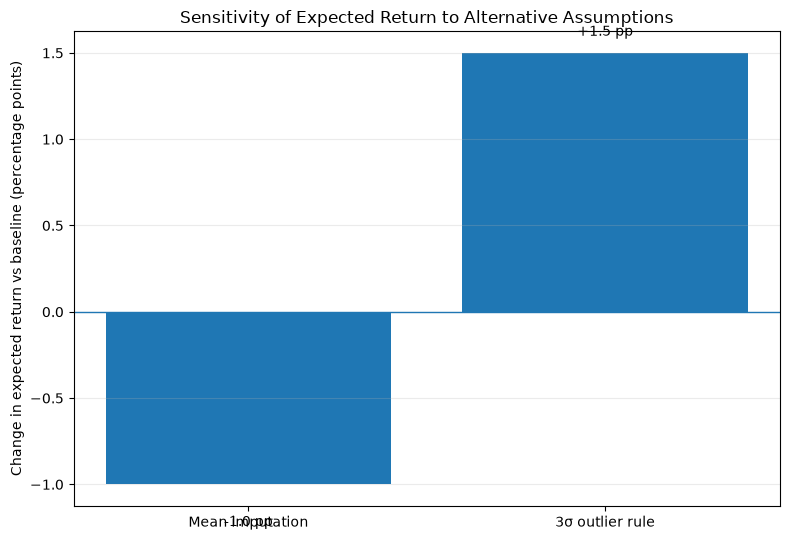

In [5]:
alt = sensitivity[sensitivity["scenario"] != "baseline"].copy()

plt.figure(figsize=(8, 5.5))
x = np.arange(len(alt))
bars = plt.bar(x, alt["return_delta_pp"])

plt.axhline(0, linewidth=1)
plt.xticks(x, alt["scenario_label"])
plt.ylabel("Change in expected return vs baseline (percentage points)")
plt.title("Sensitivity of Expected Return to Alternative Assumptions")

for bar, value in zip(bars, alt["return_delta_pp"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + (0.08 if value >= 0 else -0.18),
        f"{value:+.1f} pp",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(IMG_DIR / "return_sensitivity_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Chart 3 — Illustrative 12-month value path

To translate annual return assumptions into a familiar decision scale, this figure shows how **$100 would grow over 12 months if each scenario’s annual return accrued smoothly each month**.

This is a deterministic communication aid:

\[
V_m = 100(1+r)^{m/12}
\]

where \(r\) is the scenario-level annual return.

**Stakeholder insight:** after one year, the scenario assumptions imply values of approximately **$112.00**, **$111.00**, and **$113.50** from the same $100 starting point.

**Assumption / limitation:** real returns are not smooth. This line chart illustrates the economic size of the scenario difference; it is **not** a simulated market path or a forecast of monthly performance.


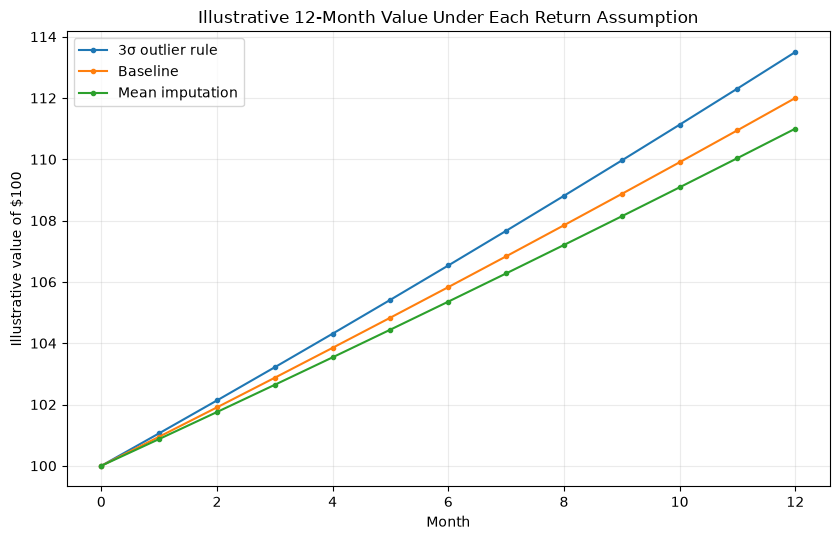

In [6]:
months = np.arange(13)
path_rows = []

for _, row in df.iterrows():
    for m in months:
        value = 100 * (1 + row["return"]) ** (m / 12)
        path_rows.append({
            "month": m,
            "scenario_label": row["scenario_label"],
            "portfolio_value": value,
        })

paths = pd.DataFrame(path_rows)

plt.figure(figsize=(8.5, 5.5))
for label, grp in paths.groupby("scenario_label"):
    plt.plot(grp["month"], grp["portfolio_value"], marker="o", markersize=3, label=label)

plt.xlabel("Month")
plt.ylabel("Illustrative value of $100")
plt.title("Illustrative 12-Month Value Under Each Return Assumption")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(IMG_DIR / "illustrative_value_path.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Assumptions & risks

### Key assumptions

1. **Scenario metrics are comparable.** Return, volatility, and Sharpe are assumed to be computed on the same horizon and methodology.
2. **Missing-data treatment matters only through the modeled scenario.** The mean-imputation scenario is treated as a controlled alternative to the baseline median assumption.
3. **Outlier treatment changes the summarized sample.** A 3σ rule can alter both return and risk because extreme observations may contain economically meaningful stress information.
4. **The illustrative value path compounds scenario return smoothly.** It is included only to communicate magnitude.

### Risks

- **Model / specification risk:** another preprocessing or modeling choice could change the ranking of scenarios.
- **Tail-risk understatement:** removing or down-weighting outliers can make historical performance look cleaner while suppressing real stress events.
- **Nonstationarity:** historical risk–return relationships may not persist.
- **Metric compression:** one Sharpe ratio can hide asymmetric downside risk and path dependence.
- **False precision:** small numerical differences should not be treated as certain forecasts.


## 8. Sensitivity summary

| Scenario | Return | Volatility | Sharpe | Return Δ vs baseline | Volatility Δ vs baseline | Sharpe Δ |
|---|---:|---:|---:|---:|---:|---:|
| Baseline | 12.0% | 18.0% | 0.56 | 0.0 pp | 0.0 pp | 0.00 |
| Mean imputation | 11.0% | 18.5% | 0.49 | -1.0 pp | +0.5 pp | -0.07 |
| 3σ outlier rule | 13.5% | 19.0% | 0.61 | +1.5 pp | +1.0 pp | +0.05 |

### Interpretation

The baseline conclusion is **moderately robust**, not assumption-free. Mean imputation worsens both return and volatility relative to baseline. The 3σ scenario improves return and Sharpe but also raises volatility. Therefore, the direction of the decision does not completely reverse, but the expected benefit changes enough that the assumption choice should be disclosed.


## 9. What this means for you

For a portfolio / risk manager:

- **Use the baseline as the planning case**, because it sits between the two alternatives and does not depend on the most optimistic treatment.
- **Carry a sensitivity range of roughly 11.0%–13.5% for expected return** rather than presenting 12.0% as a precise outcome.
- **Do not select the 3σ outlier rule solely because it raises return.** It also increases volatility, and extreme observations may contain real risk information.
- **Escalate review if preprocessing choices move expected return by more than ~1–1.5 percentage points or materially change scenario ranking.**
- Before real deployment, add downside-risk metrics and evaluate the conclusions on a held-out period or through resampling.


## 10. Generate the stakeholder report and README

The final report is intentionally shorter and less technical than this notebook. The notebook is the analyst-facing reproducibility artifact; `reports/final_report.md` is the stakeholder-facing deliverable.


In [7]:
report_text = """# Final Stakeholder Report — Results & Decision Implications

**Audience:** Portfolio / Risk Manager  
**Decision:** Whether the baseline result is robust enough for planning and how much assumption sensitivity should be carried into the decision.

## Executive Summary

- **Use the baseline as the planning case:** expected return is **12.0%**, volatility **18.0%**, and Sharpe **0.56**.
- **Carry a sensitivity range, not a single-point forecast:** expected return shifts from **11.0% to 13.5%** across the two alternative assumptions.
- **Do not treat the higher-return outlier scenario as a free improvement:** it also increases volatility, and removing extreme observations can hide economically important stress.

## 1. Risk–Return Trade-off

![Risk–Return Trade-off](images/risk_return_by_scenario.png)

**What it shows.** The baseline sits between the two alternatives. Mean imputation produces slightly lower expected return and slightly higher volatility. The 3σ outlier rule produces higher expected return, but also the highest volatility.

**What it means.** The ranking is not purely “more return is better.” The outlier scenario is more optimistic but also riskier.

**Limitation.** These are scenario outputs under different assumptions, not guaranteed future outcomes.

## 2. Sensitivity to Assumptions

![Return Sensitivity](images/return_sensitivity_vs_baseline.png)

| Scenario | Return | Volatility | Sharpe | Return Δ | Volatility Δ | Sharpe Δ |
|---|---:|---:|---:|---:|---:|---:|
| Baseline | 12.0% | 18.0% | 0.56 | 0.0 pp | 0.0 pp | 0.00 |
| Mean imputation | 11.0% | 18.5% | 0.49 | -1.0 pp | +0.5 pp | -0.07 |
| 3σ outlier rule | 13.5% | 19.0% | 0.61 | +1.5 pp | +1.0 pp | +0.05 |

**What it means.** The baseline conclusion is moderately robust, but not assumption-free. Mean imputation worsens the risk–return profile; the 3σ rule improves return and Sharpe while increasing volatility.

## 3. Economic Size of the Difference

![Illustrative Value Path](images/illustrative_value_path.png)

**What it shows.** If each scenario’s annual return accrued smoothly, $100 would end near $111.00, $112.00, or $113.50 after one year.

**What it means.** The assumption choice is economically meaningful, but the difference is measured in a few dollars per $100 over a year—not an order-of-magnitude change.

**Limitation.** This is an illustrative compounding path, not a monthly market forecast.

## Assumptions & Risks

- Scenario metrics are assumed to use the same horizon and calculation methodology.
- Mean versus median imputation can change model outputs when missing observations are not representative.
- A 3σ outlier rule may remove genuine stress observations and understate tail risk.
- Historical risk–return relationships may change over time.
- Sharpe ratio compresses risk into one number and can hide asymmetric downside behavior.
- The scenario values are estimates; small differences should not be treated as certain outcomes.

## What This Means for You

1. **Use the baseline for planning**, not the most optimistic scenario.
2. **Communicate expected return as a sensitivity range of roughly 11.0%–13.5%.**
3. **Review any preprocessing change that moves expected return by more than about 1–1.5 percentage points or reverses scenario ranking.**
4. **Do not remove extreme observations automatically**; confirm whether they are data errors or genuine risk events.
5. Before deployment, add downside-risk metrics and validate the result on unseen data or with resampling.

## Bottom Line

The analysis supports the baseline as a reasonable decision anchor, but the exact expected return depends on preprocessing assumptions. The decision is **robust in direction but sensitive in magnitude**. Stakeholders should act on the baseline while explicitly carrying the alternative scenarios as a risk range.
"""
(REPORTS_DIR / "final_report.md").write_text(report_text, encoding="utf-8")

readme_text = """# Stage 12 Reports

## Audience
The primary audience is a **portfolio / risk manager** who needs a concise decision summary rather than implementation-level detail.

## Why this format fits
The stakeholder deliverable is a short Markdown report because it is easy to review in GitHub, keeps charts and assumptions adjacent to the decisions they support, and can be exported to PDF later if needed.

The executed Jupyter notebook serves as a **second, analyst-facing format**. It contains the reproducible calculations, sensitivity table construction, chart-generation code, assumptions, and technical notes. This separation lets decision-makers receive concise conclusions while analysts can audit the workflow.

## Files
- `final_report.md` — stakeholder-facing final report
- `images/risk_return_by_scenario.png` — risk–return scatter
- `images/return_sensitivity_vs_baseline.png` — quantified scenario sensitivity
- `images/illustrative_value_path.png` — illustrative economic magnitude
- `../data/processed/final_results.csv` — scenario-level source data
- `../data/processed/sensitivity_summary.csv` — quantified sensitivity table

## Reproducibility
Run `homework12_results-reporting-delivery-design_submission.ipynb` from top to bottom. It recreates the fallback data when needed and regenerates every report figure and table.
"""
(REPORTS_DIR / "README.md").write_text(readme_text, encoding="utf-8")

print("Created:", REPORTS_DIR / "final_report.md")
print("Created:", REPORTS_DIR / "README.md")


Created: C:\Users\yifunger\Documents\Codex\2026-08-18\new-chat\work\bootcamp_Yifang_Qiu\homework\homework12\reports\final_report.md
Created: C:\Users\yifunger\Documents\Codex\2026-08-18\new-chat\work\bootcamp_Yifang_Qiu\homework\homework12\reports\README.md


## 11. Rubric checklist

### Executive Summary — 20/20 target
- ✅ 3 decision-oriented bullets
- ✅ numbers are directly tied to stakeholder action

### Visuals & Interpretation — 20/20 target
- ✅ 3 polished charts: scatter, bar, line
- ✅ titles, labels, legends / annotations
- ✅ each chart includes: what it shows, stakeholder insight, limitation
- ✅ 300 dpi exports in `reports/images/`

### Assumptions & Risks — 20/20 target
- ✅ plain-language assumptions
- ✅ preprocessing, tail-risk, nonstationarity, metric, and false-precision risks

### Sensitivity — 20/20 target
- ✅ 2 alternate scenarios
- ✅ quantified return / volatility / Sharpe deltas
- ✅ CSV sensitivity table
- ✅ sensitivity visualization
- ✅ interpretation of direction and magnitude

### Professionalism & Reproducibility — 20/20 target
- ✅ clean file organization
- ✅ descriptive filenames
- ✅ deterministic fallback
- ✅ stakeholder audience explicitly identified
- ✅ `reports/README.md`
- ✅ final artifact saved in `reports/`

### Stretch Credit — +5 target
- ✅ stakeholder-facing `reports/final_report.md`
- ✅ analyst-facing executed notebook with tailored technical depth

**Submission filename:** `homework12_results-reporting-delivery-design_submission.ipynb`
